# Postprocessing a topology optimized multiplexer with contour optimization
Topology optimization evolves grayscale device permittivity at the pixel scale and can explore a very large design space with relatively weak assumptions about the final geometry. That flexibility is especially useful for compact devices such as wavelength-division demultiplexer devices, where a good shape parameterization is hard to guess in advance. The downside is that even after binarization the resulting device is still constrained to stair-step pixel edges, which is awkward for fabrication oriented layout checks and can lose performance when converted to smooth contours.<br>
Shape-based inverse design works in the opposite regime: it optimizes explicit contours that are easier to export to GDS and easier to constrain for fabrication, but it benefits from a strong initial seed. In this notebook we combine both approaches sequentially. We start from the saved topology optimized design from [our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/), convert it into a contour representation, quantify the loss introduced by that conversion, and then fine-tune the contour to recover performance.<br>

The contour fine-tuning workflow has four stages. First we threshold the saved pixel density into a binary mask. Next `PolySlabSet.from_custom_medium(...)` extracts polygon rings, meaning closed boundary loops for the outer device contour and any interior holes. We then smooth those rings with `PolySlabSet.smooth(...)` to reduce stair-step artifacts, and finally optimize the contour vertices directly while `safe_update(...)` keeps each accepted contour valid and free of self intersections.

<img src="img/adjoint_32.png" width=500 alt="Placeholder schematic for contour-based postprocessing of a wavelength division multiplexer">


First, we import all required packages for this demo.

In [1]:
import tempfile
from pathlib import Path

import autograd.numpy as anp
import gdstk
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.autograd import (
    smooth_min,
    value_and_grad,
)
from tidy3d.plugins.invdes import PolySlabSet

## Setup
First we set up our basic simulation like in [our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/).
We have an input waveguide connected to a square design region, which has `n=4` output
waveguides.<br>
The square design region is a `CustomMedium` with a pixelated permittivity grid that we
wish to optimize such that input light of different wavelengths get directed to different
output ports.<br>
As this is a SOI device, we typically define the design region and waveguides as Silicon
sitting on an SiO2 substrate. For this demo, we make a 2D simulation, but it can be
extended to 3D by giving the structures a finite thickness through `Lz`, adding a `z`
extent to the permittivity data, and including the substrate stack.


In [2]:
# material information
n_si = 3.49
n_sio2 = 1.45  # not used in 2D
n_air = 1
nm = 1000.0  # unit conversion used in wavelength plots
eps_si = n_si**2

# channel wavelengths
wvls_design = np.array([1.270, 1.290, 1.310, 1.330])

freqs_design = td.C_0 / wvls_design
freqs_design_monitor = np.sort(freqs_design)
num_freqs_design = len(freqs_design)
freq_max = np.max(freqs_design)
freq_min = np.min(freqs_design)
keys = [str(i) for i in range(num_freqs_design)]
df_design = abs(np.mean(np.diff(freqs_design)))

# forward source
freq0 = np.mean(freqs_design)
wvl0 = td.C_0 / freq0
fwidth = freq_max - freq_min
run_time = 200 / fwidth

# we average the metrics over the channels with some frequency width
channel_fwidth = df_design / 2.0
channel_bounds = [(f - channel_fwidth / 2, f + channel_fwidth / 2) for f in freqs_design]
num_freqs_channel = 5
channel_freqs = []
for fmin, fmax in channel_bounds:
    sub_freqs = np.linspace(fmin, fmax, num_freqs_channel)
    channel_freqs += sub_freqs.tolist()
# Monitor frequency coordinates must be strictly monotone for interpolation.
channel_freqs = np.sort(np.asarray(channel_freqs, dtype=float))

# size of design region
lx = 4.5
ly = 4.5
ly_single = ly / num_freqs_design
lz = td.inf

# size of waveguides
wg_width = 0.3
wg_length = 1.5
wg_spacing = 0.8

# spacing between design region and PML in y
buffer = 1.5

# size of simulation
Lx = lx + wg_length * 2
Ly = ly + buffer * 2
Lz = 0.0


# resolution information
min_steps_per_wvl = 18
dl_design_region = 0.015
nx = int(lx / dl_design_region)
ny = int(ly / dl_design_region)

# design region and threshold settings
design_region_geo = td.Box(size=(lx, ly, lz), center=(0, 0, 0))
design_region_geometry = design_region_geo
slab_bounds = (-float("inf"), float("inf"))
permittivity_threshold = float((eps_si + 1.0) / 2.0)

core_medium = td.Medium(permittivity=eps_si)
background_medium = td.Medium(permittivity=n_air**2)

### Static Simulation
First, we'll define the simulation without any design region using the "static"
components that don't change over the optimization.<br>
We use `mode_index=0` for the source and the mode monitors, following the mode
identification in [our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/).

In [3]:
# define the waveguide ports
wg_in = td.Structure(
    geometry=td.Box(
        center=(-Lx / 2, 0, 0),
        size=(wg_length * 2, wg_width, lz),
    ),
    medium=td.Medium(permittivity=n_si**2),
)

centers_y = np.linspace(-ly / 2.0 + ly_single / 2.0, +ly / 2.0 - ly_single / 2.0, num_freqs_design)
mode_size = (0, 0.9 * ly_single, td.inf)
mode_spec = td.ModeSpec()

wgs_out = []
for center_y in centers_y:
    wg_out = td.Structure(
        geometry=td.Box(
            center=(+Lx / 2, center_y, 0),
            size=(wg_length * 2, wg_width, lz),
        ),
        medium=td.Medium(permittivity=n_si**2),
    )
    wgs_out.append(wg_out)

# measure the mode amplitudes at each of the output ports
mnts_mode = []
for key, center_y in zip(keys, centers_y):
    mnt_mode = td.ModeMonitor(
        center=(Lx / 2 - wg_length / 2, center_y, 0),
        size=mode_size,
        freqs=channel_freqs,
        mode_spec=td.ModeSpec(),
        name=f"mode_{key}",
    )
    mnts_mode.append(mnt_mode)

# measures the flux at each of the output ports
mnts_flux = []
for key, center_y in zip(keys, centers_y):
    mnt_flux = td.FluxMonitor(
        center=(Lx / 2 - wg_length / 2, center_y, 0),
        size=mode_size,
        freqs=channel_freqs,
        name=f"flux_{key}",
    )
    mnts_flux.append(mnt_flux)

# and a field monitor that measures fields on the z=0 plane at the design freqs
fld_mnt = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=freqs_design_monitor,
    name="field",
)

# inject the fundamental mode into the input waveguide
mode_src = td.ModeSource(
    center=(-Lx / 2 + wg_length / 2, 0, 0),
    size=mode_size,
    source_time=td.GaussianPulse(
        freq0=freq0,
        fwidth=fwidth,
    ),
    direction="+",
    mode_index=0,
)

sim_static = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl,
        wavelength=np.min(wvls_design),
    ),
    structures=[wg_in, *wgs_out],
    sources=[mode_src],
    monitors=[*mnts_mode, *mnts_flux, fld_mnt],
    boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=True if Lz else False),
    run_time=run_time,
)

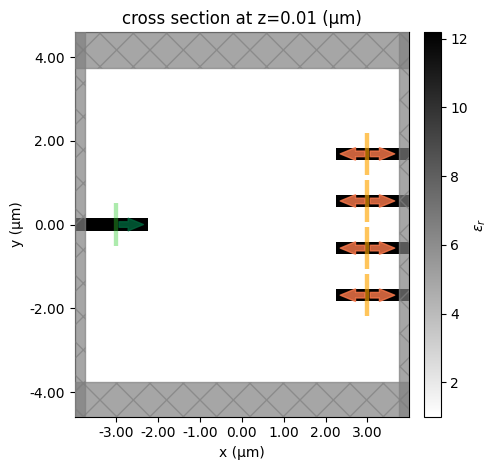

In [4]:
ax = sim_static.plot_eps(z=0.01)
ax.set_aspect("equal")

## Baseline Helpers
The next few cells define helper functions used throughout the baseline comparisons and
the contour optimization. They rebuild the current design representation, reuse the common
simulation setup, and evaluate the shared transmission metric.


### Build Design Structures
These two helpers are used whenever we switch representation (pixel, GDS export/import, contour).
They keep the simulation assembly cell clean by returning ready-to-attach structures.



In [5]:
def make_custom_design_structure(density, name):
    density_arr = np.asarray(density, dtype=float).squeeze()
    if density_arr.ndim != 2:
        raise ValueError(
            f"Expected a 2D density array after squeeze, got shape {density_arr.shape}."
        )
    eps_data = (1.0 + (eps_si - 1.0) * density_arr)[:, :, np.newaxis]
    xs = np.linspace(-lx / 2, lx / 2, density_arr.shape[0])
    ys = np.linspace(-ly / 2, ly / 2, density_arr.shape[1])
    eps_arr = td.SpatialDataArray(
        data=eps_data,
        coords={"x": xs, "y": ys, "z": [0.0]},
    )
    medium = td.CustomMedium(permittivity=eps_arr)
    return td.Structure(geometry=design_region_geo, medium=medium, name=name)

### Build Simulations for the Current Design
With the static simulation fully defined, we can write a small function that swaps in the
current design representation and chooses the monitor set we need for the next computation.
This keeps all later comparisons on the same simulation footprint and design region mesh.

In [6]:
def make_sim_with_design(design_region, freqs_mode_flux, include_field):
    mnts_mode = [
        td.ModeMonitor(
            center=(Lx / 2 - wg_length / 2, float(center_y), 0.0),
            size=mode_size,
            freqs=freqs_mode_flux,
            mode_spec=mode_spec,
            name=f"mode_{key}",
        )
        for key, center_y in zip(keys, centers_y)
    ]

    mnts_flux = [
        td.FluxMonitor(
            center=(Lx / 2 - wg_length / 2, float(center_y), 0.0),
            size=mode_size,
            freqs=freqs_mode_flux,
            name=f"flux_{key}",
        )
        for key, center_y in zip(keys, centers_y)
    ]

    monitors = [*mnts_mode, *mnts_flux]
    if include_field:
        monitors.append(
            td.FieldMonitor(
                center=(0.0, 0.0, 0.0),
                size=(td.inf, td.inf, 0),
                freqs=freqs_design_monitor,
                name="field",
            )
        )

    design_structs = (
        (design_region,) if isinstance(design_region, td.Structure) else tuple(design_region)
    )
    design_override = td.MeshOverrideStructure(
        geometry=design_region_geo,
        dl=[dl_design_region, dl_design_region, dl_design_region],
    )
    grid_spec = sim_static.grid_spec.updated_copy(
        override_structures=[*sim_static.grid_spec.override_structures, design_override]
    )
    return sim_static.updated_copy(
        structures=[*sim_static.structures, *design_structs],
        grid_spec=grid_spec,
        monitors=tuple(monitors),
    )

### Defining the Transmission Metric
With our simulation fully defined as a function of the inserted design, we can compare
pixel, GDS, and contour representations with a common scalar metric. For each output
waveguide, we average the source normalized fundamental mode power across the frequencies
inside that channel band. The channel score is the desired power within the band at that
output minus the average power from the other design channels that leaks into the same
port, so high transmission and low cross talk are rewarded at the same time. The final
transmission metric is the smooth minimum of the four channel scores, which makes the
weakest channel primarily control the loss function and the later contour update. The
metric itself is computed from linear power.


In [7]:
def average_over_channel(spectrum, fmin, fmax):
    freqs = spectrum.f
    freqs_in_channel = np.logical_and(freqs >= fmin, freqs <= fmax).values
    num_freqs = np.sum(freqs_in_channel)
    return spectrum.values @ freqs_in_channel / num_freqs


def get_power(sim_data, mnt_index, freq_index):
    mnt_data = sim_data[f"mode_{mnt_index}"]
    amp = mnt_data.amps.sel(direction="+", mode_index=0)
    power_spectrum = anp.abs(amp) ** 2
    return average_over_channel(
        spectrum=power_spectrum,
        fmin=channel_bounds[freq_index][0],
        fmax=channel_bounds[freq_index][1],
    )


def get_metric(sim_data, mnt_index):
    power_all = [
        get_power(sim_data=sim_data, mnt_index=mnt_index, freq_index=j)
        for j in range(num_freqs_design)
    ]
    power_transmitted = power_all[mnt_index]
    power_leaked = sum(power_all) - power_transmitted
    avg_power_leaked = power_leaked / float(num_freqs_design - 1)
    return power_transmitted - avg_power_leaked


def transmission_from_data(sim_data):
    metrics = [get_metric(sim_data=sim_data, mnt_index=i) for i in range(num_freqs_design)]
    return smooth_min(anp.array(metrics))


def get_transmission(design_region, task_name):
    sim = make_sim_with_design(
        design_region=design_region,
        freqs_mode_flux=channel_freqs,
        include_field=False,
    )
    data = web.run(sim, task_name=task_name, verbose=False)
    return transmission_from_data(data)

### Export to GDS and Load It Back
We next set up a reusable helper that exports the topology optimized binarized design to
GDS, loads the polygons back into Tidy3D, and returns the re-imported geometry.
Later in the notebook we use that same round-trip to quantify how much of the baseline
performance change comes from the GDS conversion itself.


In [8]:
gds_precision_um = 1e-6
gds_core_layer = 1
gds_core_dtype = 2
# Explicit contour holes are exported as background-medium structures, so both media must
# resolve to the same GDS layer for a correct single-layer roundtrip.
gds_core_layer_map = {
    core_medium: (gds_core_layer, gds_core_dtype),
    background_medium: (gds_core_layer, gds_core_dtype),
}


def gds_export_import(design_region):
    with tempfile.TemporaryDirectory(prefix="wdm_contour_gds_export_import_") as tmp:
        gds_path = Path(tmp) / "wdm_gds_export_import_pixel_exact.gds"
        design_region.to_gds_file(
            fname=str(gds_path),
            z=0.0,
            permittivity_threshold=permittivity_threshold,
            frequency=freq0,
            pixel_exact=True,
            gds_layer=gds_core_layer,
            gds_dtype=gds_core_dtype,
            gds_precision=gds_precision_um,
        )
        lib = gdstk.read_gds(str(gds_path))
        geometry = td.Geometry.from_gds(
            gds_cell=lib.cells[0],
            axis=2,
            slab_bounds=slab_bounds,
            gds_layer=gds_core_layer,
            gds_dtype=gds_core_dtype,
            merge_adjacent=True,
        )
        return td.Structure(
            geometry=geometry, medium=core_medium, name="wdm_gds_export_import_pixel_exact"
        )

### Dense Spectral Evaluation Helpers
The next helper reruns the current design with a denser wavelength sampling than the
optimization sweep so we can inspect the port resolved flux and fundamental mode
power curves in more detail. It still evaluates the same transmission objective defined
above, but on a denser wavelength grid, so small shifts relative to the earlier coarse
baseline metric come from the denser sampling rather than from a changed loss definition. The
plotting helper below then reuses that dense sweep for the later GDS, smoothed contour,
and optimized contour comparisons.


In [9]:
num_freqs_measure = 151  # dense wavelength samples for the port resolved flux and power plots


def run_dense_eval(design_region, task_name, include_field=False):
    freqs_measure = np.linspace(freq_min - df_design, freq_max + df_design, num_freqs_measure)
    sim = make_sim_with_design(
        design_region=design_region,
        freqs_mode_flux=freqs_measure,
        include_field=include_field,
    )
    sim_data = web.run(sim, task_name=task_name, verbose=False)

    wavelength_nm = None
    flux_db = []
    power_db = []

    for idx in range(num_freqs_design):
        flux_da = sim_data[f"flux_{idx}"].flux
        flux_vals = np.asarray(flux_da.values, dtype=float)
        freqs_vals = np.asarray(flux_da.f.values, dtype=float)
        wavelength_nm = (td.C_0 / freqs_vals) * nm
        flux_db.append(10.0 * np.log10(np.maximum(flux_vals, 1e-20)))

        amps = sim_data[f"mode_{idx}"].amps.sel(direction="+", mode_index=0)
        powers = np.abs(np.asarray(amps.values)) ** 2
        power_db.append(10.0 * np.log10(np.maximum(powers, 1e-20)))

    return {
        "sim": sim,
        "sim_data": sim_data,
        "wavelength_nm": np.asarray(wavelength_nm, dtype=float),
        "flux_db": np.asarray(flux_db, dtype=float),
        "power_db": np.asarray(power_db, dtype=float),
        "transmission": transmission_from_data(sim_data),
    }


def plot_dense_spectral_analysis(eval_map, flux_suptitle, power_suptitle, colors=None):
    names = list(eval_map.keys())
    datasets = list(eval_map.values())
    if colors is None:
        colors = ["black", "tab:red", "tab:orange", "tab:green", "tab:purple"][: len(datasets)]

    fig_flux, axes_flux = plt.subplots(
        1,
        num_freqs_design,
        figsize=(4.0 * num_freqs_design, 3.4),
        sharey=True,
        constrained_layout=True,
    )

    for port, ax in enumerate(axes_flux):
        fmin, fmax = channel_bounds[port]
        wvl_min = (td.C_0 / fmax) * nm
        wvl_max = (td.C_0 / fmin) * nm
        target_wvl = (td.C_0 / freqs_design[port]) * nm

        ax.axvspan(wvl_min, wvl_max, color="tab:blue", alpha=0.15)
        for name, color, ds in zip(names, colors, datasets):
            ax.plot(
                ds["wavelength_nm"], ds["flux_db"][port], color=color, linewidth=1.6, label=name
            )

        ax.scatter([target_wvl], [0.0], marker="*", s=80, color="tab:blue")
        ax.set_title(f"flux analysis, port {port}")
        ax.set_xlabel("wavelength (nm)")
        ax.grid(alpha=0.25)
        if port == 0:
            ax.set_ylabel("insertion loss (dB)")
            ax.legend(loc="best")

    fig_flux.suptitle(flux_suptitle)
    plt.show()

    fig_power, axes_power = plt.subplots(
        1,
        num_freqs_design,
        figsize=(4.0 * num_freqs_design, 3.4),
        sharey=True,
        constrained_layout=True,
    )

    for port, ax in enumerate(axes_power):
        fmin, fmax = channel_bounds[port]
        wvl_min = (td.C_0 / fmax) * nm
        wvl_max = (td.C_0 / fmin) * nm
        target_wvl = (td.C_0 / freqs_design[port]) * nm

        ax.axvspan(wvl_min, wvl_max, color="tab:blue", alpha=0.15)
        for name, color, ds in zip(names, colors, datasets):
            ax.plot(
                ds["wavelength_nm"], ds["power_db"][port], color=color, linewidth=1.6, label=name
            )

        ax.scatter([target_wvl], [0.0], marker="*", s=80, color="tab:blue")
        ax.set_title(f"mode power analysis, port {port}")
        ax.set_xlabel("wavelength (nm)")
        ax.grid(alpha=0.25)
        if port == 0:
            ax.set_ylabel("insertion loss (dB)")
            ax.legend(loc="best")

    fig_power.suptitle(power_suptitle)
    plt.show()

## Load Saved Pixel Design and Evaluate Baselines
We first load the saved pixel density array exported from the reference topology
optimization, threshold it to the pixel mask, and rebuild the corresponding
`CustomMedium`.



[baseline transmission metric]
pixel_metric=-0.554


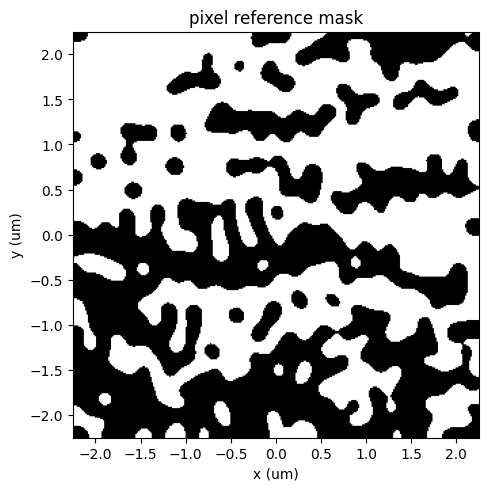

In [10]:
pixel_npy_path = Path("misc/wdm_contour_only_pixel_density.npy")

pixel_density = (np.asarray(np.load(pixel_npy_path), dtype=float) >= 0.5).astype(float)
pixel_design = make_custom_design_structure(pixel_density, name="pixel_design")

pixel_tx = get_transmission(pixel_design, task_name="wdm_pixel_baseline")

print("\n[baseline transmission metric]")
print(f"pixel_metric={pixel_tx:.3f}")

fig_pixel, ax_pixel = plt.subplots(figsize=(5.4, 4.8), constrained_layout=True)
ax_pixel.imshow(
    pixel_density.T,
    origin="lower",
    extent=(-lx / 2, lx / 2, -ly / 2, ly / 2),
    cmap="binary",
)
ax_pixel.set_title("pixel reference mask")
ax_pixel.set_aspect("equal")
ax_pixel.set_xlim(-2.25, 2.25)
ax_pixel.set_ylim(-2.25, 2.25)
ax_pixel.set_xlabel("x (um)")
ax_pixel.set_ylabel("y (um)")
plt.show()

## GDS Export / Import Comparison
We now take the binarized mask, export it to GDS with `pixel_exact=True`, load the
polygons back, and simulate that geometry again.
This shows the extra loss caused by the export/import conversion itself.<br>
The scalar metric is useful as a compact summary, but it mixes all channels together.
The dense comparison below makes the change easier to interpret port by port.


In [11]:
gds_design = gds_export_import(pixel_design)
gds_tx = get_transmission(gds_design, task_name="wdm_gds_export_import_pixel_exact")

print("\n[gds export/import transmission]")
print(f"transmission after gds conversion: {gds_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - gds_tx:.3f}")


[gds export/import transmission]
transmission after gds conversion: -0.868
loss compared to pixel reference: 0.314


### Port Resolved Spectral Comparison
To see whether the GDS conversion perturbs all outputs similarly or mainly harms one
channel, we now run the same dense wavelength sweep on the pixel reference and the
re-imported GDS geometry and compare the port resolved spectra directly.



[dense baseline transmission metric]
pixel=-0.534
gds export/import=-0.850


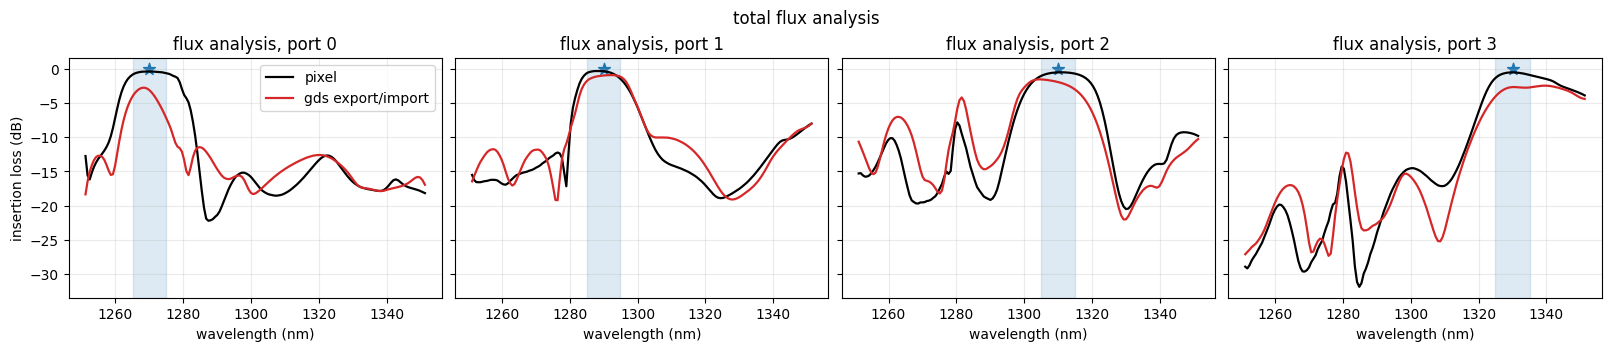

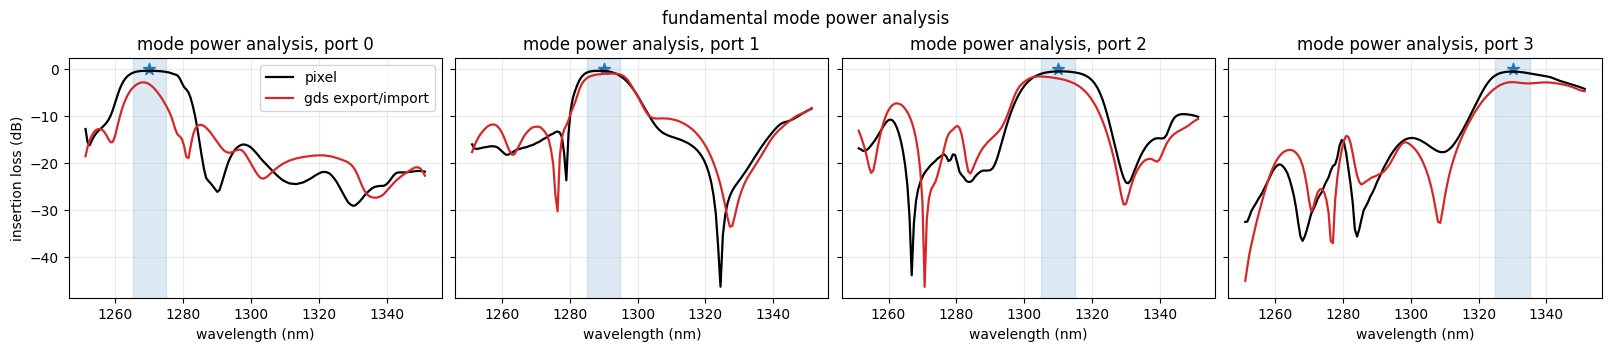

In [12]:
eval_pixel = run_dense_eval(pixel_design, task_name="wdm_eval_pixel")
eval_gds = run_dense_eval(gds_design, task_name="wdm_eval_gds_export_import_pixel_exact")

print("\n[dense baseline transmission metric]")
print(f"pixel={eval_pixel['transmission']:.3f}")
print(f"gds export/import={eval_gds['transmission']:.3f}")

plot_dense_spectral_analysis(
    {
        "pixel": eval_pixel,
        "gds export/import": eval_gds,
    },
    flux_suptitle="total flux analysis",
    power_suptitle="fundamental mode power analysis",
    colors=["black", "tab:red"],
)

## Pixel to Contour Conversion
Here we call `PolySlabSet.from_custom_medium(...)` to extract contour rings from the
binarized design. Each ring is a closed loop that represents either an outer boundary or
an interior hole.<br>
The raw stair step contour follows the pixel grid too closely to be a realistic
fabrication target, so we also smooth the rings before simulation. This improves
fabricability by reducing stair step edges while still keeping the contour close to the
binarized mask.<br>
In return, we observe some additional loss that the contour optimization will try to
recover.


In [13]:
contour_smooth_sigma = 2.0  # smoothing strength in vertex index space

contour_raw_set = PolySlabSet.from_custom_medium(
    pixel_design.medium,
    slab_bounds=slab_bounds,
    axis=2,
    threshold=permittivity_threshold,
    pixel_exact=True,
)

contour_smooth_set = contour_raw_set.smooth(contour_smooth_sigma)

contour_raw_structures = contour_raw_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_raw",
)
contour_smooth_structures = contour_smooth_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_smooth",
)

contour_raw_tx = get_transmission(contour_raw_structures, task_name="wdm_contour_raw")
contour_smooth_tx = get_transmission(contour_smooth_structures, task_name="wdm_contour_smooth")

print("\n[contour conversion transmission]")
print(f"raw contour transmission: {contour_raw_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - contour_raw_tx:.3f}")

print(f"smooth contour transmission: {contour_smooth_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - contour_smooth_tx:.3f}")


[contour conversion transmission]
raw contour transmission: -0.851
loss compared to pixel reference: 0.297
smooth contour transmission: -0.870
loss compared to pixel reference: 0.316


## Geometry Check: Raw vs. Smoothed Contour
Before running the contour optimization, we visually inspect the raw and smoothed
contours to make sure they look as expected.<br>
On the left, we plot the directly extracted contour rings from
`PolySlabSet.from_custom_medium(...)`. On the right, we plot the same rings after
Gaussian smoothing.<br>
We zoom to the design frame (`x,y in [-2.25, 2.25]`) to focus on the relevant region.


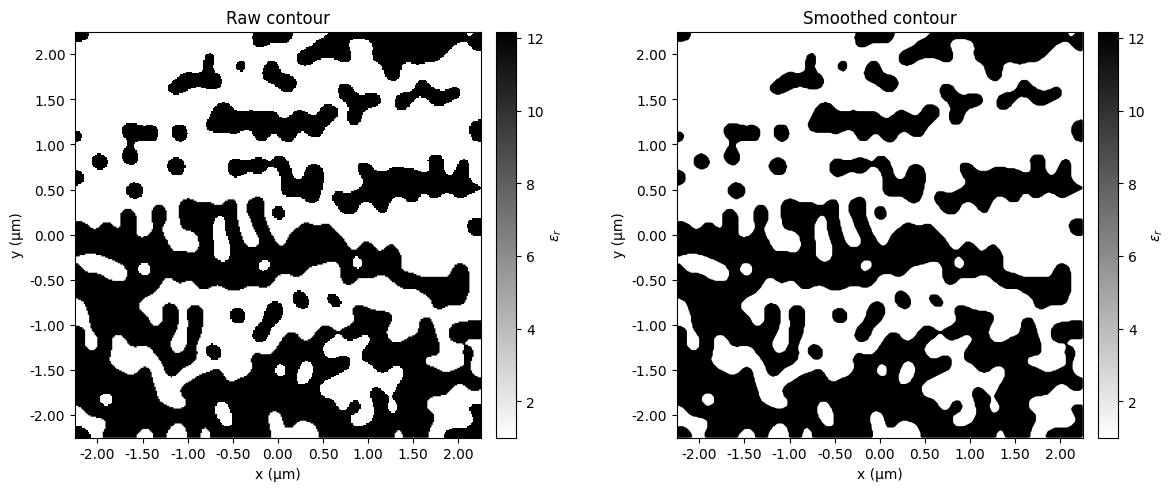

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

sim_raw_plot = sim_static.updated_copy(
    structures=[*sim_static.structures, *contour_raw_structures], monitors=[]
)
sim_smooth_plot = sim_static.updated_copy(
    structures=[*sim_static.structures, *contour_smooth_structures], monitors=[]
)

sim_raw_plot.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=axes[0])
axes[0].set_title("Raw contour")
axes[0].set_xlim(-2.25, 2.25)
axes[0].set_ylim(-2.25, 2.25)
axes[0].set_aspect("equal")

sim_smooth_plot.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=axes[1])
axes[1].set_title("Smoothed contour")
axes[1].set_xlim(-2.25, 2.25)
axes[1].set_ylim(-2.25, 2.25)
axes[1].set_aspect("equal")

plt.show()

## Defining Objective Function
With the contour representation defined, we are ready to construct the objective used for
the shape optimization stage.<br>
In this variant, the objective is just the same transmission metric defined above, still
measured from the four output waveguides.


### Map Optimizer Parameters to Valid Contours
The contour optimizer works directly in flattened vertex coordinates. In this
experimental variant we still clip candidate vertex coordinates back into the
allowed design window if a step pushes them outside it, but we do not freeze the
outer frame vertices. That lets the contour move more freely while still keeping
the update inside the design region.<br>
We evaluate gradients on the current accepted contour, then use `safe_update(...)` only
when proposing the next accepted state. That update stage enforces the bounds
rules again and rejects self intersecting candidates before they become the new
contour.


## Contour Optimization
We are now ready to optimize the contour geometry.
We optimize the smoothed contour directly in flattened vertex coordinates and keep the
last accepted contour set as the optimizer state. Each iteration evaluates the full
objective and gradient on that state, takes a plain gradient-descent style update, and
then passes the candidate through the acceptance update. That acceptance step reapplies
the bounds constraints and rejects self-intersecting candidates before they
become the next contour.<br>


In [15]:
contour_opt_steps = 25  # number of contour optimization steps
contour_opt_lr = 0.004  # optimizer learning rate

contour_current_set = contour_smooth_set
flat_reference = np.asarray(contour_current_set.flatten_ring_vertices(), dtype=float)

flat_params = flat_reference.copy()

transmission_history = []
contour_sets_over_steps = []
flat_params_over_steps = []
contour_structures_over_steps = []


def make_objective(contour_set_template):
    def objective(values):
        contour_set = contour_set_template.with_flat_ring_vertices(values)
        design_region = contour_set.to_structures(
            foreground_medium=core_medium,
            background_medium=background_medium,
            name_prefix="contour_opt",
        )
        return get_transmission(design_region=design_region, task_name="wdm_contour_opt")

    return objective


for step in range(contour_opt_steps):
    objective = make_objective(contour_current_set)
    value_grad_fn = value_and_grad(objective)
    value, gradient = value_grad_fn(flat_params)
    gradient = np.asarray(gradient, dtype=float)

    tx_current = float(value)

    transmission_history.append(tx_current)
    contour_sets_over_steps.append(contour_current_set)
    flat_params_over_steps.append(np.asarray(flat_params, dtype=float).copy())
    contour_structures_over_steps.append(
        contour_current_set.to_structures(
            foreground_medium=core_medium,
            background_medium=background_medium,
            name_prefix=f"contour_step_{step + 1}",
        )
    )

    candidate = flat_params + contour_opt_lr * gradient
    candidate_set, _ = contour_current_set.safe_update(
        candidate,
        freeze_boundary=False,
        respect_bounds=True,
    )
    contour_current_set = candidate_set
    flat_params = np.asarray(contour_current_set.flatten_ring_vertices(), dtype=float)

    print(
        f"[shape] step={step + 1:02d}, "
        f"tx={tx_current:.3f}, "
        f"grad_norm={np.linalg.norm(gradient):.3f}"
    )

contour_opt_set = contour_current_set
contour_sets_over_steps.append(contour_opt_set)
flat_params_over_steps.append(np.asarray(flat_params, dtype=float).copy())
contour_opt_structures = contour_opt_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_opt_final",
)
contour_structures_over_steps.append(contour_opt_structures)

contour_opt_tx = get_transmission(contour_opt_structures, task_name="wdm_contour_opt_final")
print(f"\noptimized contour transmission={contour_opt_tx:.3f}")

[shape] step=01, tx=-0.870, grad_norm=5.750
[shape] step=02, tx=-0.761, grad_norm=4.349
[shape] step=03, tx=-0.706, grad_norm=3.139
[shape] step=04, tx=-0.677, grad_norm=2.586
[shape] step=05, tx=-0.659, grad_norm=2.306
[shape] step=06, tx=-0.644, grad_norm=2.091
[shape] step=07, tx=-0.632, grad_norm=1.908
[shape] step=08, tx=-0.621, grad_norm=1.742
[shape] step=09, tx=-0.613, grad_norm=1.599
[shape] step=10, tx=-0.606, grad_norm=1.474
[shape] step=11, tx=-0.601, grad_norm=1.360
[shape] step=12, tx=-0.595, grad_norm=1.256
[shape] step=13, tx=-0.591, grad_norm=1.160
[shape] step=14, tx=-0.587, grad_norm=1.080
[shape] step=15, tx=-0.584, grad_norm=1.007
[shape] step=16, tx=-0.581, grad_norm=0.946
[shape] step=17, tx=-0.578, grad_norm=0.892
[shape] step=18, tx=-0.576, grad_norm=0.842
[shape] step=19, tx=-0.574, grad_norm=0.794
[shape] step=20, tx=-0.572, grad_norm=0.750
[shape] step=21, tx=-0.570, grad_norm=0.714
[shape] step=22, tx=-0.569, grad_norm=0.678
[shape] step=23, tx=-0.567, grad

## Visualize Results
Let's now inspect how the contour geometry and the optical response changed during the
shape optimization stage. On the full device scale the geometric differences are barely
visible, so we first show the global before/after view and then zoom into a few local
ring segments where the contour motion is largest.


### Structure Evolution
Instead of relying on live redraw, we render selected snapshots after optimization:
the first accepted contour state and the final accepted contour state. Because the
contour is represented as a set of polygon rings, this global comparison keeps the full
device context in view before the local zoom panels isolate the ring segments that moved
the most.


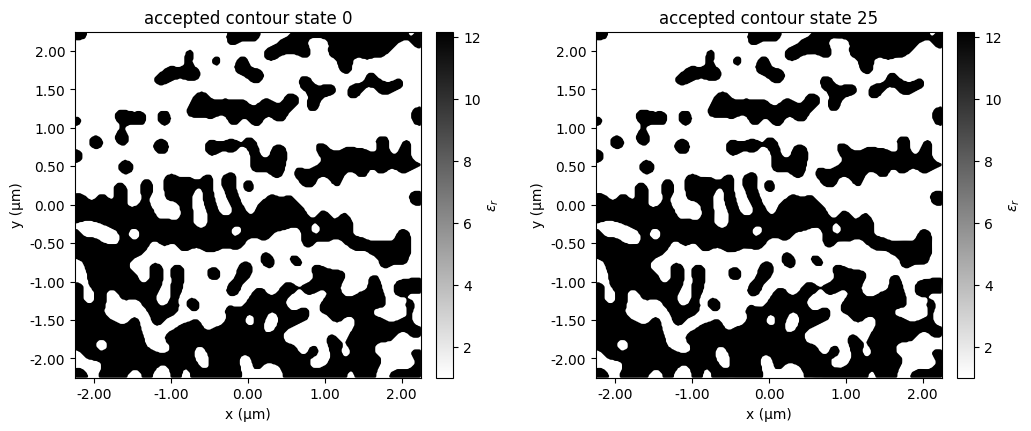

In [16]:
idx_samples = [0, len(contour_structures_over_steps) - 1]
fig_steps, axes_steps = plt.subplots(
    1, len(idx_samples), figsize=(5.2 * len(idx_samples), 4.2), constrained_layout=True
)

for ax, idx in zip(axes_steps, idx_samples):
    state_num = idx
    sim_step = sim_static.updated_copy(
        structures=[*sim_static.structures, *contour_structures_over_steps[idx]],
        monitors=[],
    )
    sim_step.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=ax)
    ax.set_title(f"accepted contour state {state_num}")
    ax.set_aspect("equal")
    ax.set_xlim(-2.25, 2.25)
    ax.set_ylim(-2.25, 2.25)

plt.show()

### Contour Difference
The contour differences are small on the full device scale, so we show the final contour
overview first and then zoom into four local comparison regions where the displacement is
largest.


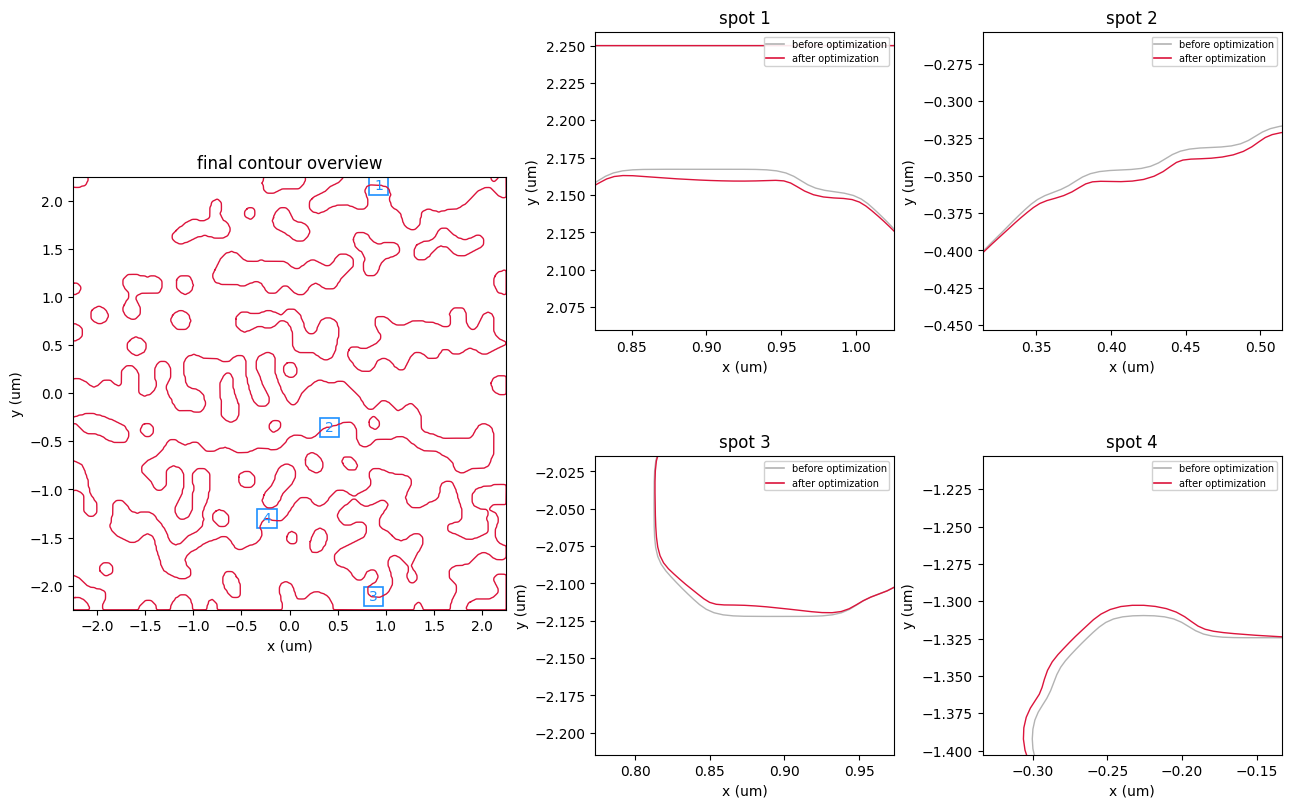

In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

flat_params_over_steps_arr = np.asarray(flat_params_over_steps, dtype=float)
vertex_xy_over_steps = flat_params_over_steps_arr.reshape(
    flat_params_over_steps_arr.shape[0], -1, 2
)
vertex_total_delta = np.linalg.norm(vertex_xy_over_steps[-1] - vertex_xy_over_steps[0], axis=1)
final_vertex_xy = vertex_xy_over_steps[-1]
zoom_half_width = 0.1
zoom_half_height = 0.1
n_focus_spots = 4

focus_spots = []
excluded_vertices = np.zeros(vertex_total_delta.shape, dtype=bool)
for _ in range(n_focus_spots):
    available_delta = np.where(excluded_vertices, -np.inf, vertex_total_delta)
    focus_vertex_idx = int(np.argmax(available_delta))
    focus_x = float(final_vertex_xy[focus_vertex_idx, 0])
    focus_y = float(final_vertex_xy[focus_vertex_idx, 1])
    focus_delta = float(vertex_total_delta[focus_vertex_idx])
    focus_spots.append((focus_vertex_idx, focus_x, focus_y, focus_delta))

    in_cutout = (np.abs(final_vertex_xy[:, 0] - focus_x) <= zoom_half_width) & (
        np.abs(final_vertex_xy[:, 1] - focus_y) <= zoom_half_height
    )
    excluded_vertices |= in_cutout

zoom_legend_handles = [
    Line2D([0], [0], color="0.7", lw=1.2, label="before optimization"),
    Line2D([0], [0], color="crimson", lw=1.2, label="after optimization"),
]

fig_diff = plt.figure(figsize=(12.8, 8.4), constrained_layout=True)
grid = fig_diff.add_gridspec(2, 3, width_ratios=(1.45, 1.0, 1.0))
ax_diff = fig_diff.add_subplot(grid[:, 0])
ax_zooms = [
    fig_diff.add_subplot(grid[0, 1]),
    fig_diff.add_subplot(grid[0, 2]),
    fig_diff.add_subplot(grid[1, 1]),
    fig_diff.add_subplot(grid[1, 2]),
]

for structure in contour_structures_over_steps[0]:
    xy = np.asarray(structure.geometry.vertices, dtype=float)
    xy_closed = np.vstack([xy, xy[0]])
    for ax_zoom in ax_zooms:
        ax_zoom.plot(xy_closed[:, 0], xy_closed[:, 1], color="0.7", lw=1.0)

for structure in contour_structures_over_steps[-1]:
    xy = np.asarray(structure.geometry.vertices, dtype=float)
    xy_closed = np.vstack([xy, xy[0]])
    ax_diff.plot(xy_closed[:, 0], xy_closed[:, 1], color="crimson", lw=1.0)
    for ax_zoom in ax_zooms:
        ax_zoom.plot(xy_closed[:, 0], xy_closed[:, 1], color="crimson", lw=1.0)

ax_diff.set_title("final contour overview")
for spot_num, (_, focus_x, focus_y, _) in enumerate(focus_spots, start=1):
    rect = Rectangle(
        (focus_x - zoom_half_width, focus_y - zoom_half_height),
        2 * zoom_half_width,
        2 * zoom_half_height,
        fill=False,
        edgecolor="dodgerblue",
        linewidth=1.2,
    )
    ax_diff.add_patch(rect)
    ax_diff.text(
        focus_x,
        focus_y,
        f"{spot_num}",
        color="dodgerblue",
        ha="center",
        va="center",
    )
ax_diff.set_aspect("equal")
ax_diff.set_xlim(-lx / 2, lx / 2)
ax_diff.set_ylim(-ly / 2, ly / 2)
ax_diff.set_xlabel("x (um)")
ax_diff.set_ylabel("y (um)")

for spot_num, (ax_zoom, (_, focus_x, focus_y, focus_delta)) in enumerate(
    zip(ax_zooms, focus_spots),
    start=1,
):
    ax_zoom.set_title(f"spot {spot_num}")
    ax_zoom.set_aspect("equal")
    ax_zoom.set_xlim(focus_x - zoom_half_width, focus_x + zoom_half_width)
    ax_zoom.set_ylim(focus_y - zoom_half_height, focus_y + zoom_half_height)
    ax_zoom.set_xlabel("x (um)")
    ax_zoom.set_ylabel("y (um)")
    ax_zoom.legend(
        handles=zoom_legend_handles,
        loc="upper right",
        fontsize=7,
        framealpha=0.9,
        borderpad=0.25,
        handlelength=1.8,
    )
plt.show()

### Transmission vs Iteration
We now track the transmission metric during contour optimization.<br>
We keep the pixel baseline and the smoothed reference contour as references.


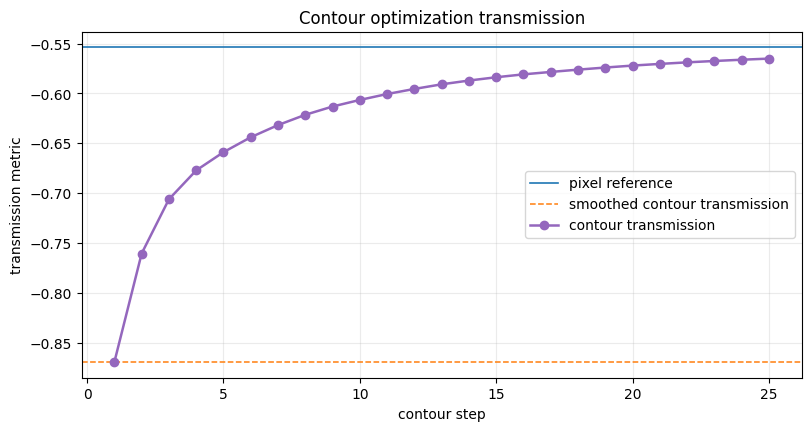

In [18]:
fig_tx, ax_tx = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
ax_tx.axhline(
    y=float(pixel_tx), color="tab:blue", linestyle="-", linewidth=1.2, label="pixel reference"
)
ax_tx.axhline(
    y=float(contour_smooth_tx),
    color="tab:orange",
    linestyle="--",
    linewidth=1.1,
    label="smoothed contour transmission",
)
ax_tx.plot(
    np.arange(1, len(transmission_history) + 1),
    transmission_history,
    marker="o",
    color="tab:purple",
    linewidth=1.8,
    label="contour transmission",
)
ax_tx.set_xlabel("contour step")
ax_tx.set_ylabel("transmission metric")
ax_tx.set_title("Contour optimization transmission")
ax_tx.grid(alpha=0.25)
ax_tx.legend(loc="best")
plt.show()

### Final Simulation
After the optimization is complete, we switch back to dense wavelength sampling so the
pixel baseline, the smoothed contour conversion, and the optimized contour can be
compared in more detail.


In [19]:
eval_contour_smooth = run_dense_eval(
    contour_smooth_structures,
    task_name="wdm_eval_contour_smooth",
)
eval_contour_opt = run_dense_eval(
    contour_opt_structures,
    task_name="wdm_eval_contour_opt",
    include_field=True,
)

### Dense Spectral Analysis
We now reuse the same dense wavelength sweep and compare the pixel reference, the
smoothed contour conversion, and the optimized contour. The printed scalar values below
are therefore the same transmission metric as before, evaluated again on this denser
wavelength grid. For each output port we plot total flux and the power in the
fundamental output mode around all channels. These spectra are shown in dB for
readability, while the optimization metric itself remains defined in linear power.



[dense transmission metric]
pixel=-0.534
smoothed contour=-0.855
optimized contour=-0.548


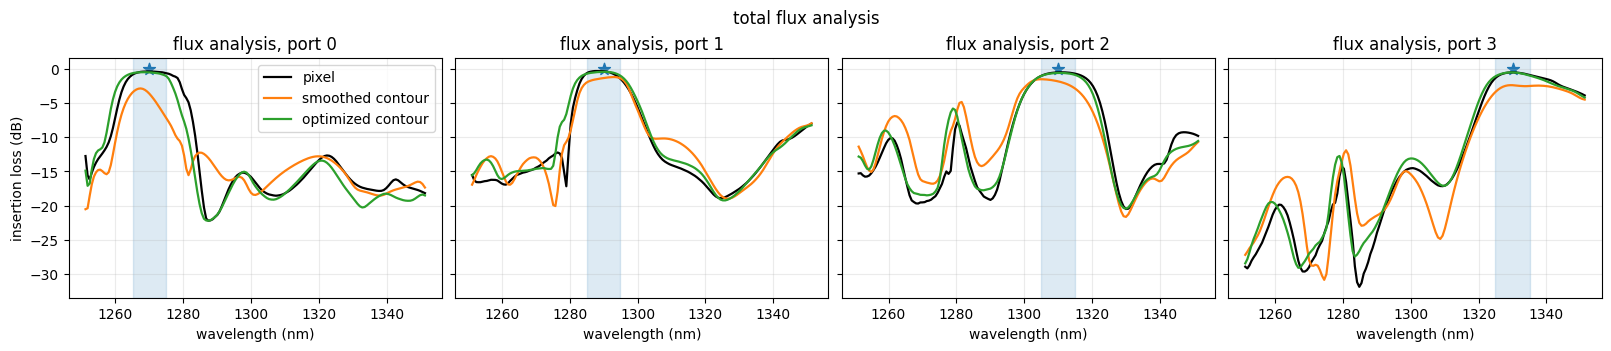

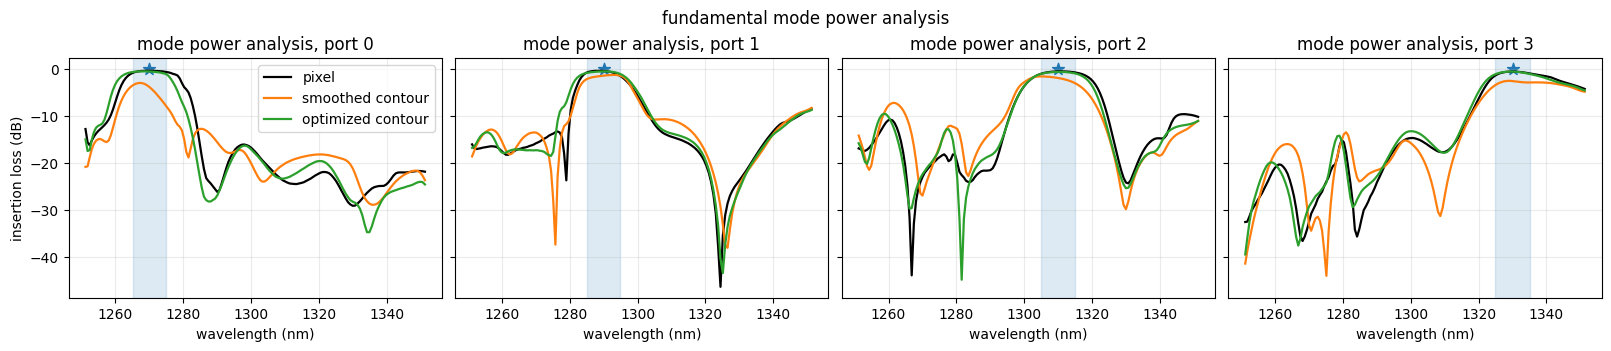

In [20]:
print("\n[dense transmission metric]")
print(f"pixel={eval_pixel['transmission']:.3f}")
print(f"smoothed contour={eval_contour_smooth['transmission']:.3f}")
print(f"optimized contour={eval_contour_opt['transmission']:.3f}")

plot_dense_spectral_analysis(
    {
        "pixel": eval_pixel,
        "smoothed contour": eval_contour_smooth,
        "optimized contour": eval_contour_opt,
    },
    flux_suptitle="total flux analysis",
    power_suptitle="fundamental mode power analysis",
    colors=["black", "tab:orange", "tab:green"],
)

### Field Analysis
Finally, we inspect the field intensity patterns at the four design wavelengths for the
optimized contour geometry.


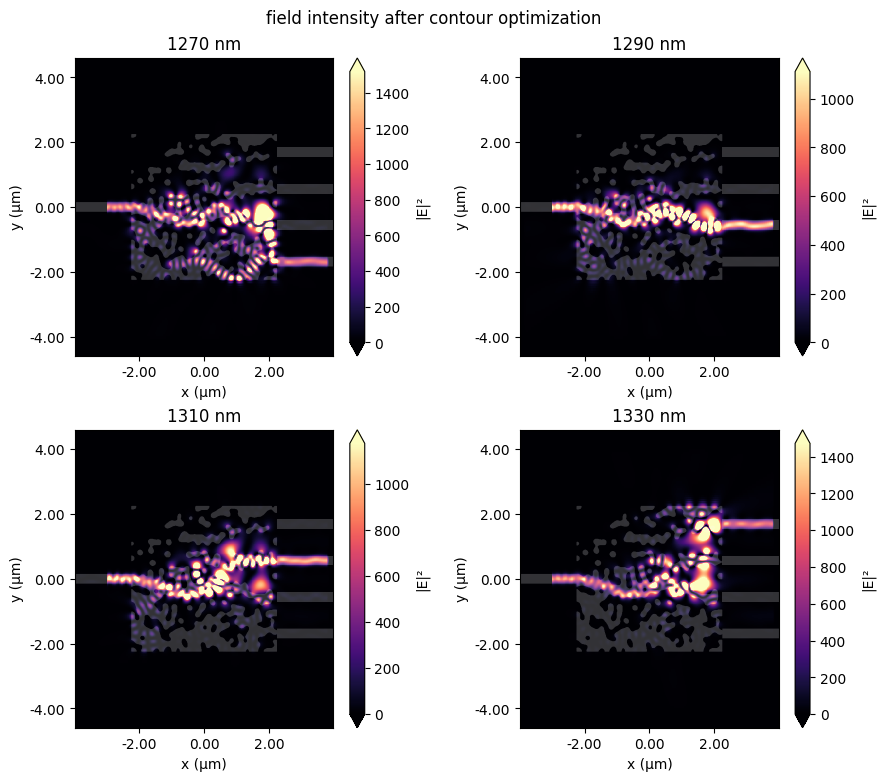

In [21]:
fig_fields, axes_fields = plt.subplots(2, 2, figsize=(8.9, 7.7), constrained_layout=True)

for freq, ax in zip(freqs_design, axes_fields.flat):
    eval_contour_opt["sim_data"].plot_field("field", "E", "abs^2", f=float(freq), ax=ax)
    wvl_nm = (td.C_0 / float(freq)) * nm
    ax.set_title(f"{round(wvl_nm)} nm")

fig_fields.suptitle("field intensity after contour optimization")
plt.show()

## Export Optimized Contour to GDS
Finally, we export the optimized contour geometry to GDS so it can be inspected or passed
to downstream layout checks. As a final consistency check, we then reload that same
single-layer GDS back into Tidy3D and evaluate the same transmission metric on the
reimported geometry.


exported optimized contour GDS to misc/wdm_contour_optimized.gds


<Axes: title={'center': 'cross section at z=0.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

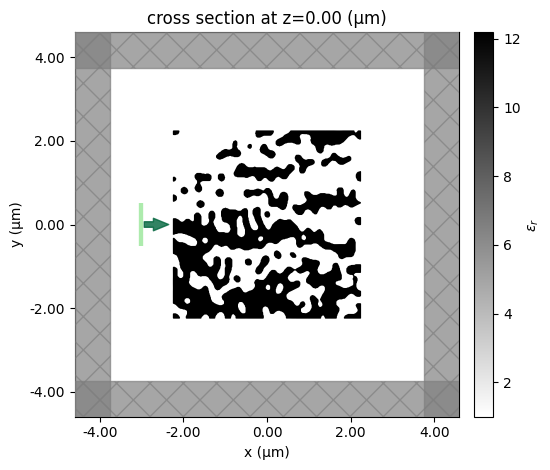

In [22]:
gds_export_dir = Path("misc")
gds_export_dir.mkdir(parents=True, exist_ok=True)
contour_opt_gds_path = gds_export_dir / "wdm_contour_optimized.gds"

contour_opt_gds_sim = sim_static.updated_copy(structures=contour_opt_structures, monitors=[])
contour_opt_gds_sim.to_gds_file(
    fname=str(contour_opt_gds_path),
    z=0.0,
    permittivity_threshold=permittivity_threshold,
    frequency=freq0,
    gds_layer_dtype_map=gds_core_layer_map,
    gds_precision=gds_precision_um,
)

print(f"exported optimized contour GDS to {contour_opt_gds_path}")

contour_opt_gds_sim.plot_eps(z=0)

### Validate the Final GDS Round-Trip
To confirm that the exported optimized contour remains consistent with the simulated
geometry, we load `misc/wdm_contour_optimized.gds` back into Tidy3D and evaluate the same
transmission metric on the reimported structure. Any remaining small loss here comes
from the finite GDS coordinate precision used during export, which slightly quantizes the
final contour vertices.


In [23]:
lib = gdstk.read_gds(str(contour_opt_gds_path))

contour_opt_gds_geometry = td.Geometry.from_gds(
    gds_cell=lib.top_level()[0],
    axis=2,
    slab_bounds=slab_bounds,
    gds_layer=gds_core_layer,
    gds_dtype=gds_core_dtype,
    merge_adjacent=True,
)
contour_opt_gds_structure = td.Structure(
    geometry=contour_opt_gds_geometry,
    medium=core_medium,
    name="wdm_contour_optimized_gds_roundtrip",
)

contour_opt_gds_tx = get_transmission(
    contour_opt_gds_structure,
    task_name="wdm_contour_optimized_gds_roundtrip",
)

print("\n[optimized contour gds roundtrip transmission]")
print(f"optimized contour={eval_contour_opt['transmission']:.3f}")
print(f"reloaded gds contour={contour_opt_gds_tx:.3f}")
print(f"roundtrip loss={eval_contour_opt['transmission'] - contour_opt_gds_tx:.3f}")


[optimized contour gds roundtrip transmission]
optimized contour=-0.548
reloaded gds contour=-0.564
roundtrip loss=0.017


## Conclusion
This notebook shows a practical way to extend topology optimization in Tidy3D with a
fabrication oriented contour stage. A saved topology optimized pixel design provides a
strong initial seed, the GDS and contour conversion steps move the representation closer
to a layout workflow, and the final contour optimization recovers part of the performance
lost during smoothing while preserving a valid polygon parameterization.<br>
The final GDS round-trip check closes that loop by verifying that the exported layout can
be loaded back into Tidy3D without introducing an additional transmission change beyond
the contour optimization result itself.<br>
More broadly, the workflow highlights how the inverse design plugins can be combined:
`CustomMedium` stores the pixel result, `PolySlabSet.from_custom_medium(...)` converts it
into rings, `smooth(...)` regularizes the geometry, `safe_update(...)` keeps accepted
contours valid, and `to_gds_file(...)` exports the final layout. That makes this a
practical bridge between high-performance topology optimization and downstream
fabrication oriented design checks.
